# **Abiotic Data Analysis**
Here, we pull salinity, sea surface temperature (SST), and precipitation data collected throughout the study and measure its impact on anemone algal density and chlorophyll concentration

## The notebook is broken into three steps:
### **Step 1) Pull and Process Abiotic Data** 
For each of the following data variables, we calculate daily and weekly averages:
* On-site SST from HOBO logger
* On-site SST and salinity from Star Oddi logger
* Off-site salinity from Fort Point buoy (located in SF Bay)
* Near-site precipitation from nearby terrestrial datasets

We also pull SST data from one of NOAA’s ERDDAP satellite datasets (Dataset ID: jplMURSST41).

### **Step 2) Visualize collected SST and Salinity data**
### **Step 3) Regression Analysis**

In [1]:
# load some library
import sys
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import xarray as xr

sys.path.append(os.path.expanduser('../../'))
from utils.functions import process_abiotic_data, site_sample_area
from utils.visuals import abiotic_plot, regression

## **Step 1) Pull and Process Abiotic Data**
* Set collection start and end dates (with a few additional weeks buffer)
* Calculate weekly and daily averages for each dataset

In [ ]:
abiotic_data_path = 'abiotic_data/'
start_date = '2022-08-01T00:00:00'
end_date = '2023-03-31T00:00:00'
data, seven_day_averages_data, daily_averages_data = process_abiotic_data(abiotic_data_path, start_date, end_date)

Available datasets:
- hobo
- star_oddi
- fort_point_daily
- fort_point_hourly
- precipitation

Available 7-day average datasets:
- hobo_seven_day_average
- star_oddi_seven_day_average
- fort_point_daily_seven_day_average
- fort_point_hourly_seven_day_average
- precipitation_seven_day_average

Available daily average datasets:
- hobo_daily_average
- star_oddi_daily_average
- fort_point_daily_daily_average
- fort_point_hourly_daily_average
- precipitation_daily_average


In [3]:
# Accessing the datasets
hobo_data = data['hobo']
star_oddi_data = data['star_oddi']
fort_point_daily_data = data['fort_point_daily']
fort_point_hourly_data = data['fort_point_hourly']
precipitation_data = data['precipitation']

hobo_seven_day_average_data = seven_day_averages_data['hobo_seven_day_average']
star_oddi_seven_day_average_data = seven_day_averages_data['star_oddi_seven_day_average']
fort_point_seven_day_average_data = seven_day_averages_data['fort_point_daily_seven_day_average']
fort_point_seven_day_hourly_average_data = seven_day_averages_data['fort_point_hourly_seven_day_average']
precipitation_seven_day_average_data = seven_day_averages_data['precipitation_seven_day_average']

hobo_average_data = daily_averages_data['hobo_daily_average']
star_oddi_average_data = daily_averages_data['star_oddi_daily_average']
fort_point_daily_average_data = daily_averages_data['fort_point_daily_daily_average']
fort_point_hourly_average_data = daily_averages_data['fort_point_hourly_daily_average']
precipitation_average_data = daily_averages_data['precipitation_daily_average']

## **Pull SST data from one of NOAA’s ERDDAP satellite datasets**

## Open a pointer to open the dataset

* These new variables will hold all the data for that link
* We'll run one below so you can see what it looks like
---

In [ ]:
mur_sst_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41'
mur_anom_month_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anommday'
mur_sst_month__url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41mday'

sst = xr.open_dataset(mur_sst_url)
month_sst_anom = xr.open_dataset(mur_anom_month_url)
month_sst = xr.open_dataset(mur_sst_month__url)

### Create a small square area for satellite data to retrieve from, offshore about 5km

In [6]:
start_time = '2022-08-27T12:00:00'
end_time = '2023-04-22T12:00:00'
data = sst

ap_beach = site_sample_area(data=data, start_time=start_time, end_time=end_time,site='ap')

lon: -122.580725 -122.54072500000001
lat: 37.527919000000004 37.567919


In [7]:
ap_beach

<xarray.DataArray 'analysed_sst' (time: 238, latitude: 4, longitude: 4)>
[3808 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 2022-08-28T09:00:00 ... 2023-04-22T09:00:00
  * latitude   (latitude) float32 37.53 37.54 37.55 37.56
  * longitude  (longitude) float32 -122.6 -122.6 -122.6 -122.6
Attributes:
    colorBarMaximum:  32.0
    colorBarMinimum:  0.0
    comment:          Interim near-real-time (nrt) version using Multi-Resolu...
    ioos_category:    Temperature
    long_name:        Analysed Sea Surface Temperature
    source:           MODIS_T-JPL, MODIS_A-JPL, AMSR2-REMSS, AVHRRMTB_G-NAVO,...
    standard_name:    sea_surface_foundation_temperature
    units:            degree_C
    valid_max:        57.767
    valid_min:        -7.767000000000003

## **Step 2) Visualize collected SST and Salinity data**

# Visualize SST from data loggers and satellite data

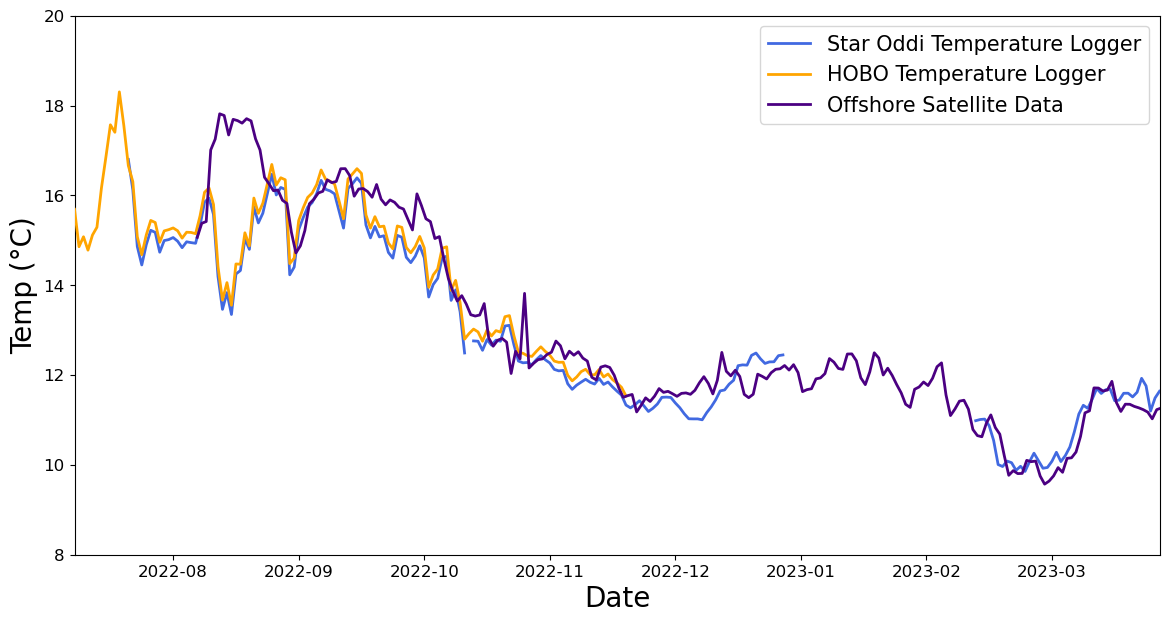

In [8]:
data_dict = {
    'Star Oddi Temperature Logger': (star_oddi_average_data['date_time'], star_oddi_average_data['temp_c_daily_average'], 'royalblue', 'line'),
    'HOBO Temperature Logger': (hobo_average_data['date_time'], hobo_average_data['temp_c_daily_average'], 'orange', 'line'),
    'Offshore Satellite Data': (ap_beach.time, ap_beach.mean(axis=(1,2)), 'indigo', 'line')
}

abiotic_plot('line', data_dict, 
            #'Fall Temperature Decrease Similarly Detected \n with Satellite and Intertidal Loggers', 
            xlabel='Date', ylabel='Temp (°C)', 
            xlim=(start_date, end_date), 
            ylim=(8, 20), 
            save_path='plots/temperature_trends_no_title.png')


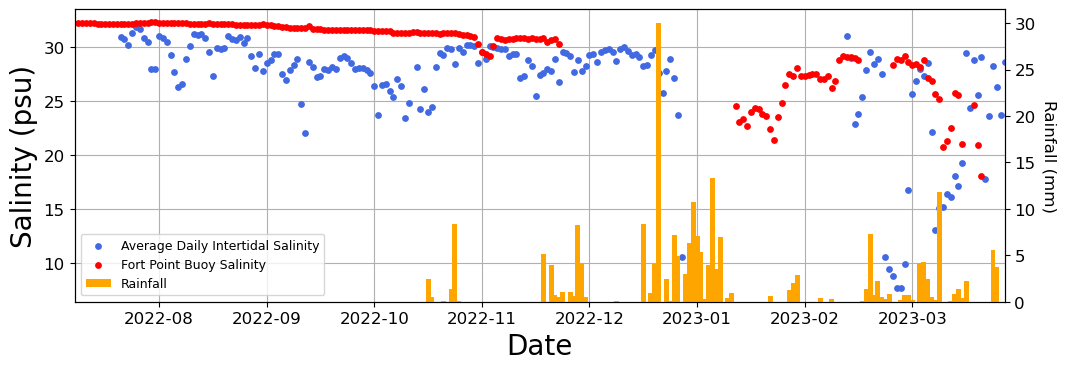

In [9]:
data_dict = {
    'Average Daily Intertidal Salinity': (star_oddi_average_data['date_time'], star_oddi_average_data['salinity_ppt_daily_average'], 'royalblue', 'scatter'),
    'Fort Point Buoy Salinity': (fort_point_daily_average_data['date_time'], fort_point_daily_average_data['salinity_ppt_daily_average'], 'red', 'scatter'),
    'rain': (precipitation_data['date_time'], precipitation_data['rain_mm'], 'orange', 'bar')
}

abiotic_plot('scatter', data_dict, 
            #'Local Rain Events Drastically Drop Intertidal Logger Salinity', 
            xlabel='Date', ylabel='Salinity (psu)', 
            xlim=(start_date, end_date), 
            save_path='figures/salinity_rainfall_no_title.png')

## **Step 3) Regression Analysis**

Pull cleaned algal density and chlorophyll concentration datasets from `biotic_data_analysis.ipynb`

In [24]:
a_sola_algae_data = pd.read_csv('biotic_data/a_sola_algae_data.csv')
a_sola_algae_data = a_sola_algae_data[['date_time', 'num_cells_per_ug_protein']]

a_sola_chl_data = pd.read_csv('biotic_data/a_sola_chlorophyll_data.csv')
a_sola_chl_data = a_sola_chl_data[['date_time', 'ng_chlorophyll_per_ug_protein']]

In [29]:
# Ensure date_time is treated as a datetime object (optional but recommended)
a_sola_chl_data['date_time'] = pd.to_datetime(a_sola_chl_data['date_time'])
a_sola_algae_data['date_time'] = pd.to_datetime(a_sola_algae_data['date_time'])


# Group by date_time and calculate the mean
average_chl_by_date = a_sola_chl_data.groupby('date_time', as_index=False)['ng_chlorophyll_per_ug_protein'].mean()
average_algae_by_date = a_sola_algae_data.groupby('date_time', as_index=False)['num_cells_per_ug_protein'].mean()

average_algae_by_date = average_algae_by_date.rename(columns={'num_cells_per_ug_protein':'avg_num_cells_per_ug_protein'})
average_chl_by_date = average_chl_by_date.rename(columns={'ng_chlorophyll_per_ug_protein':'avg_ng_chlorophyll_per_ug_protein'})

avg_biotic_dependent_vars = pd.merge(average_algae_by_date, average_chl_by_date, on='date_time', how='outer')

In [30]:
avg_biotic_dependent_vars

,date_time,avg_num_cells_per_ug_protein,avg_ng_chlorophyll_per_ug_protein
0,2022-08-27,1229.109180,59.551621
1,2022-08-28,1410.625774,81.910197
2,2022-09-06,1165.674312,95.228443
3,2022-09-07,1241.706010,91.605877
4,2022-09-23,1274.936744,60.079010
5,2022-09-24,939.042052,58.627409
6,2022-10-10,1169.361765,NaN
7,2022-10-11,1022.189948,NaN
8,2022-10-27,1375.186657,74.407994
9,2022-10-28,707.755169,28.967448


In [ ]:
# Ensure date_time is treated as a datetime object
a_sola_algae_data['date_time'] = pd.to_datetime(a_sola_algae_data['date_time'])

# Group by date_time and calculate the mean
average_algae_by_date = a_sola_algae_data.groupby('date_time', as_index=False)['num_cells_per_ug_protein'].mean()

average_algae_by_date = average_algae_by_date.rename(columns={'num_cells_per_ug_protein':'avg_num_cells_per_ug_protein'})

# Display result
print(average_algae_by_date)

    date_time  avg_num_cells_per_ug_protein
0  2022-08-27                   1229.109180
1  2022-08-28                   1410.625774
2  2022-09-06                   1165.674312
3  2022-09-07                   1241.706010
4  2022-09-23                   1274.936744
5  2022-09-24                    939.042052
6  2022-10-10                   1169.361765
7  2022-10-11                   1022.189948
8  2022-10-27                   1375.186657
9  2022-10-28                    707.755169
10 2022-11-08                   1494.118142
11 2022-11-23                    695.890378
12 2022-12-06                    612.884032
13 2023-01-06                    685.421340
14 2023-01-23                    588.035318
15 2023-02-06                    563.501745
16 2023-02-18                    599.270588
17 2023-03-17                    447.340753


In [12]:
# Sort both DataFrames by date_time (required for merge_asof)
algae_data = average_algae_by_date
temp_data = star_oddi_seven_day_average_data.sort_values('date_time')

# Perform an asof merge to find the closest matching date
avg_algae_abiotic_data = pd.merge_asof(algae_data, temp_data, on='date_time', direction='nearest')

# Display the merged data
print(avg_algae_abiotic_data)

    date_time  avg_num_cells_per_ug_protein  temp_c_seven_day_average  \
0  2022-08-27                   1229.109180                 15.140396   
1  2022-08-28                   1410.625774                 15.140396   
2  2022-09-06                   1165.674312                 14.362901   
3  2022-09-07                   1241.706010                 14.362901   
4  2022-09-23                   1274.936744                 15.936019   
5  2022-09-24                    939.042052                 15.936019   
6  2022-10-10                   1169.361765                 15.016051   
7  2022-10-11                   1022.189948                 15.016051   
8  2022-10-27                   1375.186657                 14.007658   
9  2022-10-28                    707.755169                 12.827494   
10 2022-11-08                   1494.118142                 12.661708   
11 2022-11-23                    695.890378                 11.893495   
12 2022-12-06                    612.884032        

In [13]:
# Average over lat/lon to get a time series of daily SST
daily_satellite_sst = ap_beach.mean(dim=['latitude', 'longitude']).to_series()
daily_satellite_sst.index = pd.to_datetime(daily_satellite_sst.index)  # Ensure datetime index

In [14]:
satellite_sst_7day_avg = daily_satellite_sst.rolling(window=7, min_periods=1).mean()

In [15]:
# Step 1: Turn your SST series into a DataFrame
satellite_sst_df = satellite_sst_7day_avg.reset_index()
satellite_sst_df.columns = ['date_time', 'satellite_temp_avg']

# Step 2: Ensure both are sorted by date
avg_algae_abiotic_data = avg_algae_abiotic_data.sort_values('date_time')
satellite_sst_df = satellite_sst_df.sort_values('date_time')

# Step 3: Use merge_asof to find nearest SST for each algae sample date
avg_algae_abiotic_data = pd.merge_asof(
    avg_algae_abiotic_data,
    satellite_sst_df,
    on='date_time',
    direction='nearest',          # You can try 'backward' or 'forward' if you want to limit
    tolerance=pd.Timedelta('7D')  # Only use SST if it's within 7 days
)

# Step 4: Fill NaNs with the satellite SST values
avg_algae_abiotic_data['temp_c_seven_day_average'] = avg_algae_abiotic_data['temp_c_seven_day_average'].fillna(
    avg_algae_abiotic_data['satellite_temp_avg']
)

# (Optional) Drop the satellite column afterward
avg_algae_abiotic_data = avg_algae_abiotic_data.drop(columns=['satellite_temp_avg'])


In [ ]:
model = regression(avg_algae_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Temperature \n (7-day average prior to sampling)',
                   save_path='plots/temp_algal_density_regression.png')

In [ ]:
model = regression(avg_algae_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Salinity \n (7-day average prior to sampling)',
                   save_path='plots/salinity_algal_density_regression.png')

                                 OLS Regression Results                                 
Dep. Variable:     avg_num_cells_per_ug_protein   R-squared:                       0.293
Model:                                      OLS   Adj. R-squared:                  0.238
Method:                           Least Squares   F-statistic:                     5.383
Date:                          Sun, 11 Jan 2026   Prob (F-statistic):             0.0372
Time:                                  12:49:06   Log-Likelihood:                -105.44
No. Observations:                            15   AIC:                             214.9
Df Residuals:                                13   BIC:                             216.3
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------

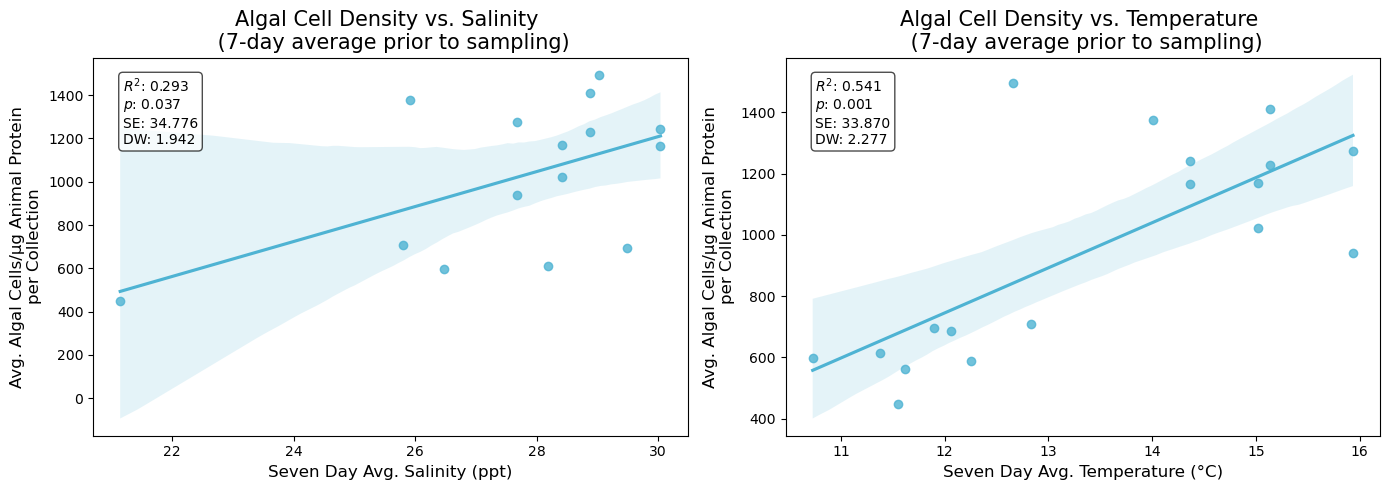

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regression(avg_algae_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Salinity \n (7-day average prior to sampling)',
                   ax=axes[0]
)                

regression(avg_algae_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Temperature \n (7-day average prior to sampling)',
                   ax=axes[1])


plt.tight_layout()
fig.savefig("plots/subplot_algae_salinity_temp_regression.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# Ensure date_time is treated as a datetime object (optional but recommended)
a_sola_chl_data['date_time'] = pd.to_datetime(a_sola_chl_data['date_time'])

# Group by date_time and calculate the mean
average_chl_by_date = a_sola_chl_data.groupby('date_time', as_index=False)['ng_chlorophyll_per_ug_protein'].mean()

average_chl_by_date = average_chl_by_date.rename(columns={'ng_chlorophyll_per_ug_protein':'avg_ng_chlorophyll_per_ug_protein'})

# Display result
print(average_chl_by_date)

    date_time  avg_ng_chlorophyll_per_ug_protein
0  2022-08-27                          59.551621
1  2022-08-28                          81.910197
2  2022-09-06                          95.228443
3  2022-09-07                          91.605877
4  2022-09-23                          60.079010
5  2022-09-24                          58.627409
6  2022-10-27                          74.407994
7  2022-10-28                          28.967448
8  2022-11-08                          66.489613
9  2022-11-23                          71.075774
10 2022-12-06                          51.234062
11 2023-01-06                          33.471221
12 2023-01-23                          26.836452
13 2023-02-06                          15.725405
14 2023-02-18                          19.353205
15 2023-03-17                          18.292696


In [26]:
# Sort both DataFrames by date_time (required for merge_asof)
chl_data = average_chl_by_date
temp_data = star_oddi_seven_day_average_data.sort_values('date_time')

# Perform an asof merge to find the closest matching date
avg_chl_abiotic_data = pd.merge_asof(chl_data, temp_data, on='date_time', direction='nearest')

# Display the merged data
print(avg_chl_abiotic_data)

    date_time  avg_ng_chlorophyll_per_ug_protein  temp_c_seven_day_average  \
0  2022-08-27                          59.551621                 15.140396   
1  2022-08-28                          81.910197                 15.140396   
2  2022-09-06                          95.228443                 14.362901   
3  2022-09-07                          91.605877                 14.362901   
4  2022-09-23                          60.079010                 15.936019   
5  2022-09-24                          58.627409                 15.936019   
6  2022-10-27                          74.407994                 14.007658   
7  2022-10-28                          28.967448                 12.827494   
8  2022-11-08                          66.489613                 12.661708   
9  2022-11-23                          71.075774                 11.893495   
10 2022-12-06                          51.234062                 11.375797   
11 2023-01-06                          33.471221                

In [ ]:
# Step 1: Turn your SST series into a DataFrame
satellite_sst_df = satellite_sst_7day_avg.reset_index()
satellite_sst_df.columns = ['date_time', 'satellite_temp_avg']

# Step 2: Ensure both are sorted by date
avg_chl_abiotic_data = avg_chl_abiotic_data.sort_values('date_time')
satellite_sst_df = satellite_sst_df.sort_values('date_time')

# Step 3: Use merge_asof to find nearest SST for each algae sample date
avg_chl_abiotic_data = pd.merge_asof(
    avg_chl_abiotic_data,
    satellite_sst_df,
    on='date_time',
    direction='nearest',          # You can try 'backward' or 'forward' if you want to limit
    tolerance=pd.Timedelta('7D')  # Only use SST if it's within 7 days
)

# Step 4: Fill NaNs with the satellite SST values
avg_chl_abiotic_data['temp_c_seven_day_average'] = avg_chl_abiotic_data['temp_c_seven_day_average'].fillna(
    avg_chl_abiotic_data['satellite_temp_avg']
)

# (Optional) Drop the satellite column afterward
avg_chl_abiotic_data = avg_chl_abiotic_data.drop(columns=['satellite_temp_avg'])


In [ ]:
model = regression(avg_chl_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Temperature \n (7-day average prior to sampling)',
                   save_path='plots/temperature_chlorophyll_density_regression.png')

In [ ]:
model = regression(avg_chl_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Salinity \n (7-day average prior to sampling)',
                   save_path='plots/salinity_chlorophyll_density_regression.png')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regression(avg_chl_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Salinity \n (7-day average prior to sampling)',
                   ax=axes[0])

regression(avg_chl_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Temperature \n (7-day average prior to sampling)',
                   ax=axes[1])

plt.tight_layout()
fig.savefig("plots/subplot_chl_salinity_temp_regression.png", dpi=300, bbox_inches="tight")
plt.show()